# Forecasting Public AI Adoption Risk Sentiment

This notebook collects public Reddit comments and NewsAPI records about major AI companies and tools. It converts the text into sentiment and risk-related features, aggregates those features by week, and trains a feedforward neural network to predict next-week public AI adoption risk sentiment.

The model is compared against a historical mean baseline. The goal is to forecast public risk sentiment based on observable discussion patterns.


## 1. Install Required Packages


In [1]:
!pip install praw vaderSentiment pandas numpy scikit-learn matplotlib requests joblib tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.8 MB/s eta 0:00:00


## 2. API Keys


In [ ]:
REDDIT_CLIENT_ID = ""
REDDIT_CLIENT_SECRET = ""
REDDIT_USER_AGENT = ""

NEWS_API_KEY = ""


## 3. Imports


In [3]:
#Basic utilities.
import re
import time
from pathlib import Path

#Data and numerical work.
import numpy as np
import pandas as pd

#API collection.
import praw
import requests

#Charts.
import matplotlib.pyplot as plt

#Sentiment analysis.
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#Modeling and evaluation.
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#Save the feature scaler.
import joblib

#Make results repeatable.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 4. Project Settings

This section controls the output folder, date range, collection limits, Reddit search terms, and NewsAPI queries.

Reddit and NewsAPI uses broad AI risk/adoption search terms to collect enough public discussion.


In [8]:
# Save final outputs to a new clean folder.
# This keeps the final feedforward neural network outputs separate from older notebook runs.
OUTPUT_DIR = Path("ai_risk_company_final_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep records from the modern generative AI period.
START_DATE = "2023-01-01"
START_TIMESTAMP = pd.Timestamp(START_DATE, tz="UTC")

# Reddit collection settings.
# The total comment cap keeps the notebook manageable and helps avoid Reddit rate limits.
TOTAL_REDDIT_COMMENTS = 1100
POSTS_PER_SEARCH = 50
MAX_COMMENTS_PER_POST = 5
MAX_COMMENTS_PER_WEEK = 35
SLEEP_SECONDS = 3

# NewsAPI usually returns a limited number of articles per request.
# Using several company-specific queries gives better coverage than one broad AI query.
MAX_NEWS_ARTICLES_PER_QUERY = 20

SUBREDDITS = [
    "artificial",
    "ArtificialInteligence",
    "technology",
    "MachineLearning",
    "singularity",
    "OpenAI",
    "ChatGPT"
]

# Company/tool-specific Reddit searches.
# These replace broad searches like "AI safety" so the data stays focused on major AI companies/tools.

SEARCH_TERMS = [
    "AI risk",
    "AI safety",
    "AI regulation",
    "AI privacy",
    "AI security",
    "AI misinformation",
    "AI hallucination",
    "AI job loss",
    "AI copyright",
    "AI adoption risk"
]

# Company/tool-specific NewsAPI searches.
NEWS_QUERIES = [
    "OpenAI OR ChatGPT risk OR safety OR privacy",
    "Anthropic OR Claude risk OR safety OR security",
    "Google Gemini OR DeepMind risk OR safety",
    "Microsoft Copilot risk OR privacy OR security",
    "Meta Llama OR Meta AI risk OR privacy",
    "xAI OR Grok risk OR misinformation",
]


## 5. Keywords

Risk keywords create the supervision label. Company keywords identify the main AI company or topic.


In [5]:
RISK_KEYWORDS = [
    "risk", "risky", "danger", "dangerous", "unsafe", "safety", "harm", "harmful",
    "threat", "scary", "concern", "concerns", "worried", "worry", "fear", "fears",
    "warning", "warned", "catastrophic", "existential", "existential risk", "x-risk",
    "regulation", "regulated", "regulatory", "law", "laws", "lawsuit", "legal",
    "compliance", "policy", "ban", "banned", "restriction", "oversight",
    "governance", "liability", "accountability",
    "privacy", "security", "cybersecurity", "breach", "leak", "data leak",
    "data breach", "surveillance", "tracking", "personal data", "sensitive data",
    "confidential", "unauthorized", "exploit", "vulnerability", "attack",
    "bias", "biased", "discrimination", "discriminatory", "fairness", "unfair",
    "racism", "sexism", "harmful content", "toxic", "toxicity", "harassment",
    "misinformation", "disinformation", "fake news", "deepfake", "deepfakes",
    "hallucination", "hallucinations", "false information", "fabricated",
    "deceptive", "deception", "propaganda", "manipulation", "impersonation",
    "job loss", "job losses", "layoff", "layoffs", "automation", "unemployment",
    "replace workers", "replace jobs", "job displacement", "displacement",
    "workers replaced", "economic disruption",
    "copyright", "intellectual property", "ip theft", "plagiarism", "training data",
    "scraped data", "data scraping", "artist rights", "creator rights", "stolen data",
    "failure", "fails", "failed", "bug", "bugs", "glitch", "incident", "outage",
    "unreliable", "inaccurate", "accuracy problem", "black box", "lack of transparency",
    "not transparent", "unexplainable", "alignment", "misaligned", "jailbreak",
    "prompt injection", "model collapse",
    "military", "warfare", "weapon", "weapons", "autonomous weapons",
    "surveillance state", "policing", "facial recognition", "healthcare risk",
    "financial risk", "fraud", "scam", "scams",
    "supply chain", "reputation", "reputational", "legal risk", "operational risk",
    "third-party risk", "vendor risk", "compliance risk", "data risk"
]

COMPANY_KEYWORDS = {
    "OpenAI": ["openai", "chatgpt", "gpt-4", "gpt-5", "gpt"],
    "Anthropic": ["anthropic", "claude"],
    "Google": ["google ai", "gemini", "deepmind"],
    "Microsoft": ["microsoft copilot", "copilot", "azure ai", "microsoft ai"],
    "Meta": ["meta ai", "meta", "llama", "llama 3", "llama 4", "facebook ai"],
    "xAI": ["xai", "x.ai", "grok"],
}


## 6. Helper Functions

These functions clean text, match risk keywords, identify company/tool mentions, and convert dates.

Company matching uses the full available text field. For Reddit, that field includes the post title plus the comment text so comments are not incorrectly labeled as general AI when the company only appears in the post title.


In [6]:
def clean_text(text):
    """Clean raw text from Reddit or news."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^A-Za-z0-9\s\-\.']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_text_for_matching(text):
    """Clean and lowercase text before keyword matching."""
    return clean_text(text).lower()


def keyword_in_text(keyword, normalized_text):
    """Return True when a keyword appears as a phrase or whole term."""
    pattern = r"(?<![a-z0-9])" + re.escape(keyword.lower()) + r"(?![a-z0-9])"
    return re.search(pattern, normalized_text) is not None


def contains_any_keyword(text, keywords):
    """Return 1 if any keyword appears in the text; otherwise return 0."""
    normalized = normalize_text_for_matching(text)
    for keyword in keywords:
        if keyword_in_text(keyword, normalized):
            return 1
    return 0


def count_risk_keywords(text):
    """Count how many risk keywords appear in the text."""
    normalized = normalize_text_for_matching(text)
    count = 0
    for keyword in RISK_KEYWORDS:
        if keyword_in_text(keyword, normalized):
            count += 1
    return count


def assign_company_or_topic(text):
    """Assign the main company/tool mentioned in the text."""
    normalized = normalize_text_for_matching(text)
    matched = []

    for company, keywords in COMPANY_KEYWORDS.items():
        for keyword in keywords:
            if keyword_in_text(keyword, normalized):
                matched.append(company)
                break

    matched = sorted(set(matched))

    if len(matched) == 0:
        return "General AI"
    if len(matched) == 1:
        return matched[0]
    return "Multiple"


def reddit_timestamp_to_datetime(created_utc):
    """Convert Reddit Unix time to a timezone-aware datetime."""
    return pd.to_datetime(created_utc, unit="s", utc=True)


def parse_news_datetime(value):
    """Convert NewsAPI publishedAt values to datetime."""
    return pd.to_datetime(value, utc=True, errors="coerce")


## 7. Collect Reddit Comments


In [9]:
def get_reddit_client():
    """
    Create and return a Reddit API client using the key variables set directly in the notebook.
    """
    reddit = praw.Reddit(
        client_id=REDDIT_CLIENT_ID,
        client_secret=REDDIT_CLIENT_SECRET,
        user_agent=REDDIT_USER_AGENT
    )
    return reddit


def collect_reddit_comments(
    subreddits,
    search_terms,
    total_comment_limit=1100,
    posts_per_search=40,
    max_comments_per_post=6,
    max_comments_per_week=30,
    sleep_seconds=3
):
    """
    Collect actual Reddit comments from posts matching the selected subreddits and search terms.

    Each row is one Reddit comment.
    The total comment count is capped.
    Comments per post and comments per week are capped to spread the data over time.
    """

    reddit = get_reddit_client()
    records = []
    seen_comment_ids = set()
    weekly_counts = {}

    sort_options = ["relevance", "top", "comments", "new"]
    time_filters = ["year", "all"]

    for subreddit_name in subreddits:
        subreddit = reddit.subreddit(subreddit_name)

        for term in search_terms:
            for sort_option in sort_options:
                for time_filter in time_filters:

                    print(
                        f"Collecting comments from r/{subreddit_name} | "
                        f"term: {term} | sort: {sort_option} | time: {time_filter}"
                    )

                    for submission in subreddit.search(
                        term,
                        sort=sort_option,
                        time_filter=time_filter,
                        limit=posts_per_search
                    ):
                        submission.comments.replace_more(limit=0)
                        comments = submission.comments.list()[:max_comments_per_post]

                        for comment in comments:
                            if len(records) >= total_comment_limit:
                                return pd.DataFrame(records)

                            if comment.id in seen_comment_ids:
                                continue

                            comment_created_dt = reddit_timestamp_to_datetime(comment.created_utc)

                            if pd.Timestamp(comment_created_dt) < START_TIMESTAMP:
                                continue

                            comment_week = pd.to_datetime(comment_created_dt).to_period("W").start_time

                            if comment_week not in weekly_counts:
                                weekly_counts[comment_week] = 0

                            if weekly_counts[comment_week] >= max_comments_per_week:
                                continue

                            seen_comment_ids.add(comment.id)
                            weekly_counts[comment_week] += 1

                            records.append({
                                "source": "reddit_comment",
                                "subreddit": subreddit_name,
                                "search_term": term,
                                "title": submission.title,
                                "body": comment.body,
                                "text": f"{submission.title} {comment.body}",
                                "created_at": comment_created_dt,
                                "week": comment_week,
                                "score": comment.score,
                                "num_comments": submission.num_comments,
                                "url": f"https://www.reddit.com{comment.permalink}",
                                "post_url": f"https://www.reddit.com{submission.permalink}",
                                "post_score": submission.score,
                                "comment_id": comment.id,
                                "post_id": submission.id
                            })

                            if len(records) >= total_comment_limit:
                                return pd.DataFrame(records)

                    time.sleep(sleep_seconds)

    return pd.DataFrame(records)


# Collect actual Reddit comments.
TOTAL_REDDIT_COMMENTS = 1100
POSTS_PER_SEARCH = 40
MAX_COMMENTS_PER_POST = 6
MAX_COMMENTS_PER_WEEK = 30
SLEEP_SECONDS = 0

reddit_df = collect_reddit_comments(
    subreddits=SUBREDDITS,
    search_terms=SEARCH_TERMS,
    total_comment_limit=TOTAL_REDDIT_COMMENTS,
    posts_per_search=POSTS_PER_SEARCH,
    max_comments_per_post=MAX_COMMENTS_PER_POST,
    max_comments_per_week=MAX_COMMENTS_PER_WEEK,
    sleep_seconds=SLEEP_SECONDS
)

print("Reddit comment records collected:", len(reddit_df))

if len(reddit_df) == 0:
    raise ValueError("No Reddit comments were collected. Check the Reddit API keys, subreddit names, or search terms.")

print("Reddit weekly date spread:")
print(reddit_df["week"].value_counts().sort_index())

raw_reddit_path = OUTPUT_DIR / "raw_reddit_ai_comments.csv"
reddit_df.to_csv(raw_reddit_path, index=False)
print("Saved raw Reddit comment data to:", raw_reddit_path)

reddit_df.head()

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

/tmp/ipykernel_4776/3720773111.py:71: UserWarning: Converting to Period representation will drop timezone information.
  comment_week = pd.to_datetime(comment_created_dt).to_period("W").start_time
It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/mu

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

...

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Reddit comment records collected: 1100
Reddit weekly date spread:
week
2023-02-13     6
2023-02-20     6
2023-03-27     6
2023-05-01    12
2023-05-29     6
              ..
2026-04-13    30
2026-04-20    30
2026-04-27    30
2026-05-04    30
2026-05-11     4
Name: count, Length: 104, dtype: int64
Saved raw Reddit comment data to: ai_risk_company_final_outputs/raw_reddit_ai_comments.csv


,source,subreddit,search_term,title,body,text,created_at,week,score,num_comments,url,post_url,post_score,comment_id,post_id
0,reddit_comment,artificial,AI risk,AI automation is NOT just an economic issue. L...,"I was thinking about this the other day, for s...",AI automation is NOT just an economic issue. L...,2025-09-07 11:46:54+00:00,2025-09-01,18,112,https://www.reddit.com/r/artificial/comments/1...,https://www.reddit.com/r/artificial/comments/1...,260,ncw1g8j,1naob47
1,reddit_comment,artificial,AI risk,AI automation is NOT just an economic issue. L...,"*walks outside, meets three homeless people on...",AI automation is NOT just an economic issue. L...,2025-09-07 15:58:52+00:00,2025-09-01,3,112,https://www.reddit.com/r/artificial/comments/1...,https://www.reddit.com/r/artificial/comments/1...,260,ncx9t8y,1naob47
2,reddit_comment,artificial,AI risk,AI automation is NOT just an economic issue. L...,When was the last time an oppressive governmen...,AI automation is NOT just an economic issue. L...,2025-09-07 13:00:22+00:00,2025-09-01,5,112,https://www.reddit.com/r/artificial/comments/1...,https://www.reddit.com/r/artificial/comments/1...,260,ncwbyv8,1naob47
3,reddit_comment,artificial,AI risk,AI automation is NOT just an economic issue. L...,[removed],AI automation is NOT just an economic issue. L...,2025-09-07 12:22:10+00:00,2025-09-01,6,112,https://www.reddit.com/r/artificial/comments/1...,https://www.reddit.com/r/artificial/comments/1...,260,ncw69qg,1naob47
4,reddit_comment,artificial,AI risk,AI automation is NOT just an economic issue. L...,AI are going to run everything. People will st...,AI automation is NOT just an economic issue. L...,2025-09-07 16:50:11+00:00,2025-09-01,2,112,https://www.reddit.com/r/artificial/comments/1...,https://www.reddit.com/r/artificial/comments/1...,260,ncxk63f,1naob47


## 8. Collect NewsAPI Articles


In [10]:
def collect_newsapi_articles(queries, page_size=20):
    """Collect required company/tool-specific AI news records from NewsAPI."""

    endpoint = "https://newsapi.org/v2/everything"
    records = []
    seen_urls = set()

    for query in queries:
        params = {
            "q": query,
            "language": "en",
            "sortBy": "publishedAt",
            "pageSize": page_size,
            "apiKey": NEWS_API_KEY
        }

        print(f"Collecting NewsAPI records for query: {query}")
        response = requests.get(endpoint, params=params, timeout=30)
        response.raise_for_status()
        articles = response.json().get("articles", [])

        for article in articles:
            title = article.get("title") or ""
            description = article.get("description") or ""
            content = article.get("content") or ""
            url = article.get("url")
            published_at = parse_news_datetime(article.get("publishedAt"))

            if pd.isna(published_at):
                continue

            if pd.Timestamp(published_at) < START_TIMESTAMP:
                continue

            if url in seen_urls:
                continue

            text = f"{title} {description} {content}"
            company_or_topic = assign_company_or_topic(text)

            # Keep only records that mention a tracked company/tool.
            if company_or_topic == "General AI":
                continue

            seen_urls.add(url)

            records.append({
                "source": "newsapi_article",
                "subreddit": None,
                "search_term": query,
                "title": title,
                "body": description,
                "text": text,
                "created_at": published_at,
                "week": pd.to_datetime(published_at).to_period("W").start_time,
                "score": None,
                "num_comments": None,
                "url": url,
                "post_url": url,
                "post_score": None,
                "comment_id": None,
                "post_id": None,
                "initial_company_or_topic": company_or_topic
            })

    return pd.DataFrame(records)


news_df = collect_newsapi_articles(NEWS_QUERIES, page_size=MAX_NEWS_ARTICLES_PER_QUERY)
print("News records collected:", len(news_df))

if len(news_df) == 0:
    raise ValueError("No news records were collected. Check the NewsAPI key, queries, or date filter.")

print("News company/topic counts:")
print(news_df["initial_company_or_topic"].value_counts())

raw_news_path = OUTPUT_DIR / "raw_company_specific_newsapi_articles.csv"
news_df.to_csv(raw_news_path, index=False)
print("Saved raw NewsAPI articles to:", raw_news_path)

display(news_df.head())


/tmp/ipykernel_4776/1469796665.py:55: UserWarning: Converting to Period representation will drop timezone information.
  "week": pd.to_datetime(published_at).to_period("W").start_time,


News records collected: 12
News company/topic counts:
initial_company_or_topic
Anthropic    4
Meta         4
OpenAI       2
Google       1
Multiple     1
Name: count, dtype: int64
Saved raw NewsAPI articles to: ai_risk_company_final_outputs/raw_company_specific_newsapi_articles.csv


,source,subreddit,search_term,title,body,text,created_at,week,score,num_comments,url,post_url,post_score,comment_id,post_id,initial_company_or_topic
0,newsapi_article,None,Anthropic OR Claude risk OR safety OR security,cognitive-core-mcp 0.5.1,Standalone MCP server bridging Claude Code (or...,cognitive-core-mcp 0.5.1 Standalone MCP server...,2026-05-10 21:12:15+00:00,2026-05-04,None,None,https://pypi.org/project/cognitive-core-mcp/0....,https://pypi.org/project/cognitive-core-mcp/0....,None,None,None,Anthropic
1,newsapi_article,None,Anthropic OR Claude risk OR safety OR security,cognitive-core-mcp added to PyPI,Standalone MCP server bridging Claude Code (or...,cognitive-core-mcp added to PyPI Standalone MC...,2026-05-10 21:12:08+00:00,2026-05-04,None,None,https://pypi.org/project/cognitive-core-mcp/,https://pypi.org/project/cognitive-core-mcp/,None,None,None,Anthropic
2,newsapi_article,None,Google Gemini OR DeepMind risk OR safety,"Google Maps stopped being ""just a map"" the mom...","Google Maps feels less like search, more like ...","Google Maps stopped being ""just a map"" the mom...",2026-05-10 21:00:22+00:00,2026-05-04,None,None,https://www.xda-developers.com/google-maps-sto...,https://www.xda-developers.com/google-maps-sto...,None,None,None,Google
3,newsapi_article,None,Google Gemini OR DeepMind risk OR safety,SEO Refresher – Refresh blog posts with AI to ...,Refresh blog posts with AI to boost SEO and AE...,SEO Refresher – Refresh blog posts with AI to ...,2026-05-10 20:52:20+00:00,2026-05-04,None,None,https://betalist.com/startups/seo-refresher,https://betalist.com/startups/seo-refresher,None,None,None,Anthropic
4,newsapi_article,None,Google Gemini OR DeepMind risk OR safety,Tech Giants’ Cash Reserve Shrinks Amid $725 Bi...,Record spending on artificial intelligence by ...,Tech Giants’ Cash Reserve Shrinks Amid $725 Bi...,2026-05-10 20:41:10+00:00,2026-05-04,None,None,https://www.pymnts.com/artificial-intelligence...,https://www.pymnts.com/artificial-intelligence...,None,None,None,Meta


## 9. Combine and Clean Data

This section combines Reddit and news records, removes duplicates, creates the risk label, and assigns each record to a tracked company/tool.

Records that do not mention a tracked company/tool are removed so the final dataset does not become general AI discussion data.


In [11]:
# Combine Reddit and news data.
raw_df = pd.concat([reddit_df, news_df], ignore_index=True)

combined_raw_path = OUTPUT_DIR / "combined_raw_company_specific_reddit_news.csv"
raw_df.to_csv(combined_raw_path, index=False)
print("Saved combined raw dataset to:", combined_raw_path)

# Prepare the final record-level dataset.
df = raw_df.copy()
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df = df.dropna(subset=["created_at", "text"])

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].copy()

# Remove exact duplicate cleaned text.
df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)

# Recreate week and month columns.
df["week"] = df["created_at"].dt.to_period("W").apply(lambda period: period.start_time)
df["month"] = df["created_at"].dt.to_period("M").astype(str)

# Create labels and topic fields.
df["risk_label"] = df["clean_text"].apply(lambda text: contains_any_keyword(text, RISK_KEYWORDS))
df["risk_keyword_count"] = df["clean_text"].apply(count_risk_keywords)
df["company_or_topic"] = df["clean_text"].apply(assign_company_or_topic)

# Remove records that still do not mention a tracked company/tool.
df = df[df["company_or_topic"] != "General AI"].copy()

print("Combined records before cleaning:", len(raw_df))
print("Total usable company-specific records after cleaning:", len(df))
print("Date range:", df["created_at"].min(), "to", df["created_at"].max())
print("Company/topic counts:")
print(df["company_or_topic"].value_counts())

processed_records_path = OUTPUT_DIR / "processed_company_specific_record_level_dataset.csv"
df.to_csv(processed_records_path, index=False)
print("Saved processed record-level dataset to:", processed_records_path)

display(df.head())


Saved combined raw dataset to: ai_risk_company_final_outputs/combined_raw_company_specific_reddit_news.csv


/tmp/ipykernel_4776/1236045276.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["created_at"].dt.to_period("W").apply(lambda period: period.start_time)
/tmp/ipykernel_4776/1236045276.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M").astype(str)


Combined records before cleaning: 1112
Total usable company-specific records after cleaning: 321
Date range: 2023-02-14 05:06:37+00:00 to 2026-05-11 03:03:49+00:00
Company/topic counts:
company_or_topic
OpenAI       140
Anthropic     87
Multiple      32
Google        20
Meta          17
xAI           17
Microsoft      8
Name: count, dtype: int64
Saved processed record-level dataset to: ai_risk_company_final_outputs/processed_company_specific_record_level_dataset.csv


,source,subreddit,search_term,title,body,text,created_at,week,score,num_comments,...,post_url,post_score,comment_id,post_id,initial_company_or_topic,clean_text,month,risk_label,risk_keyword_count,company_or_topic
6,reddit_comment,artificial,AI risk,Scientific American: Can a Chatbot be Consciou...,Excellent use case for: \n\nhttps://en.m.wikip...,Scientific American: Can a Chatbot be Consciou...,2025-07-29 16:29:35+00:00,2025-07-28,19,117,...,https://www.reddit.com/r/artificial/comments/1...,34,n5thev0,1mc83cw,NaN,Scientific American Can a Chatbot be Conscious...,2025-07,0,0,Anthropic
7,reddit_comment,artificial,AI risk,Scientific American: Can a Chatbot be Consciou...,People go back and forth with their intuitions...,Scientific American: Can a Chatbot be Consciou...,2025-07-29 18:14:27+00:00,2025-07-28,6,117,...,https://www.reddit.com/r/artificial/comments/1...,34,n5u4hep,1mc83cw,NaN,Scientific American Can a Chatbot be Conscious...,2025-07,1,1,Anthropic
8,reddit_comment,artificial,AI risk,Scientific American: Can a Chatbot be Consciou...,Maybe Claude is expressing uncertainty about i...,Scientific American: Can a Chatbot be Consciou...,2025-07-31 05:39:15+00:00,2025-07-28,3,117,...,https://www.reddit.com/r/artificial/comments/1...,34,n646p6p,1mc83cw,NaN,Scientific American Can a Chatbot be Conscious...,2025-07,0,0,Anthropic
9,reddit_comment,artificial,AI risk,Scientific American: Can a Chatbot be Consciou...,We are going to come to the conclusion that we...,Scientific American: Can a Chatbot be Consciou...,2025-07-29 14:07:59+00:00,2025-07-28,15,117,...,https://www.reddit.com/r/artificial/comments/1...,34,n5snhi5,1mc83cw,NaN,Scientific American Can a Chatbot be Conscious...,2025-07,0,0,Anthropic
10,reddit_comment,artificial,AI risk,Scientific American: Can a Chatbot be Consciou...,It seems likely that they have something on th...,Scientific American: Can a Chatbot be Consciou...,2025-07-29 16:42:47+00:00,2025-07-28,5,117,...,https://www.reddit.com/r/artificial/comments/1...,34,n5tk8h1,1mc83cw,NaN,Scientific American Can a Chatbot be Conscious...,2025-07,0,0,Anthropic


## 10. Sentiment Features


In [12]:
sentiment_analyzer = SentimentIntensityAnalyzer()
sentiment_scores = df["clean_text"].apply(sentiment_analyzer.polarity_scores)
sentiment_df = pd.DataFrame(list(sentiment_scores)).rename(columns={
    "neg": "vader_neg",
    "neu": "vader_neu",
    "pos": "vader_pos",
    "compound": "vader_compound"
})

df = pd.concat([df.reset_index(drop=True), sentiment_df.reset_index(drop=True)], axis=1)

# Convert compound sentiment to a negative sentiment score from 0 to 1.
df["negative_sentiment_score"] = (1 - df["vader_compound"]) / 2

# Record-level risk sentiment score combines risk keywords and sentiment.
df["record_risk_sentiment_score"] = (
    0.65 * df["risk_label"] +
    0.25 * df["negative_sentiment_score"] +
    0.10 * df["risk_keyword_count"].clip(upper=5) / 5
)
df["record_risk_sentiment_score"] = df["record_risk_sentiment_score"].clip(0, 1)

record_features_path = OUTPUT_DIR / "record_level_sentiment_features.csv"
df.to_csv(record_features_path, index=False)
print("Saved record-level sentiment features to:", record_features_path)

display(df[["created_at", "source", "company_or_topic", "risk_label", "risk_keyword_count", "vader_compound", "record_risk_sentiment_score", "clean_text"]].head())


Saved record-level sentiment features to: ai_risk_company_final_outputs/record_level_sentiment_features.csv


,created_at,source,company_or_topic,risk_label,risk_keyword_count,vader_compound,record_risk_sentiment_score,clean_text
0,2025-07-29 16:29:35+00:00,reddit_comment,Anthropic,0,0,0.1779,0.102763,Scientific American Can a Chatbot be Conscious...
1,2025-07-29 18:14:27+00:00,reddit_comment,Anthropic,1,1,-0.9890,0.918625,Scientific American Can a Chatbot be Conscious...
2,2025-07-31 05:39:15+00:00,reddit_comment,Anthropic,0,0,-0.6597,0.207462,Scientific American Can a Chatbot be Conscious...
3,2025-07-29 14:07:59+00:00,reddit_comment,Anthropic,0,0,-0.1531,0.144138,Scientific American Can a Chatbot be Conscious...
4,2025-07-29 16:42:47+00:00,reddit_comment,Anthropic,0,0,0.4767,0.065412,Scientific American Can a Chatbot be Conscious...


## 11. Basic Visual Checks

These charts confirm the class balance and whether the dataset is focused on tracked AI companies/tools.


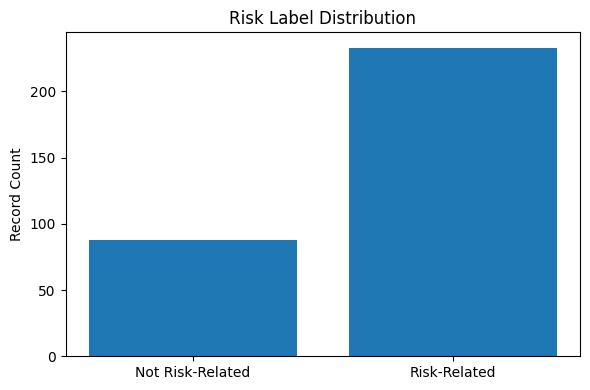

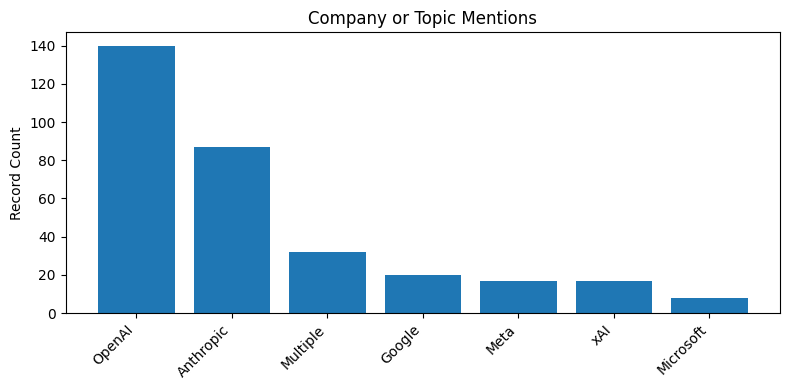

In [13]:
# Risk label distribution.
label_counts = df["risk_label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Risk-Related", "Risk-Related"], [label_counts.get(0, 0), label_counts.get(1, 0)])
plt.title("Risk Label Distribution")
plt.ylabel("Record Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "risk_label_distribution.png", dpi=150)
plt.show()

# Company/topic distribution.
company_counts = df["company_or_topic"].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(company_counts.index, company_counts.values)
plt.title("Company or Topic Mentions")
plt.ylabel("Record Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "company_topic_distribution.png", dpi=150)
plt.show()


## 12. Weekly Feature Engineering

The target is next-week risk sentiment. Lag and rolling features give the feedforward neural network recent history.


In [14]:
# Create company/topic dummy columns.
company_dummies = pd.get_dummies(df["company_or_topic"], prefix="company")
company_columns = list(company_dummies.columns)
weekly_source_df = pd.concat([df.reset_index(drop=True), company_dummies.reset_index(drop=True)], axis=1)

# Aggregate records into weekly features.
weekly_df = weekly_source_df.groupby("week").agg(
    total_records=("risk_label", "count"),
    risk_records=("risk_label", "sum"),
    avg_sentiment=("vader_compound", "mean"),
    avg_negative_sentiment=("negative_sentiment_score", "mean"),
    avg_risk_keyword_count=("risk_keyword_count", "mean"),
    risk_sentiment_score=("record_risk_sentiment_score", "mean")
).reset_index()

weekly_company_counts = weekly_source_df.groupby("week")[company_columns].sum().reset_index()
weekly_df = weekly_df.merge(weekly_company_counts, on="week", how="left")

weekly_df["risk_rate"] = weekly_df["risk_records"] / weekly_df["total_records"]
weekly_df = weekly_df.sort_values("week").reset_index(drop=True)

# Lag features.
weekly_df["lag_1_risk_sentiment_score"] = weekly_df["risk_sentiment_score"].shift(1)
weekly_df["lag_2_risk_sentiment_score"] = weekly_df["risk_sentiment_score"].shift(2)
weekly_df["lag_3_risk_sentiment_score"] = weekly_df["risk_sentiment_score"].shift(3)
weekly_df["lag_1_risk_rate"] = weekly_df["risk_rate"].shift(1)
weekly_df["lag_1_avg_sentiment"] = weekly_df["avg_sentiment"].shift(1)
weekly_df["lag_1_avg_negative_sentiment"] = weekly_df["avg_negative_sentiment"].shift(1)

# Rolling average features.
weekly_df["rolling_3_risk_sentiment_score"] = weekly_df["risk_sentiment_score"].rolling(window=3).mean()
weekly_df["rolling_4_risk_sentiment_score"] = weekly_df["risk_sentiment_score"].rolling(window=4).mean()
weekly_df["rolling_3_avg_sentiment"] = weekly_df["avg_sentiment"].rolling(window=3).mean()
weekly_df["rolling_3_risk_rate"] = weekly_df["risk_rate"].rolling(window=3).mean()

# Target: next-week risk sentiment score.
weekly_df["target_next_week_risk_score"] = weekly_df["risk_sentiment_score"].shift(-1)

# Drop rows that cannot be used because of missing lag history or missing target.
weekly_model_df = weekly_df.dropna(subset=[
    "lag_1_risk_sentiment_score",
    "lag_2_risk_sentiment_score",
    "lag_3_risk_sentiment_score",
    "rolling_3_risk_sentiment_score",
    "rolling_4_risk_sentiment_score",
    "target_next_week_risk_score"
]).copy()

weekly_features_path = OUTPUT_DIR / "weekly_ai_risk_sentiment_features.csv"
weekly_model_path = OUTPUT_DIR / "weekly_model_ready_dataset.csv"
weekly_df.to_csv(weekly_features_path, index=False)
weekly_model_df.to_csv(weekly_model_path, index=False)

print("Weekly rows before lag filtering:", len(weekly_df))
print("Weekly rows available for modeling:", len(weekly_model_df))
print("Saved weekly features to:", weekly_features_path)
print("Saved model-ready weekly dataset to:", weekly_model_path)

display(weekly_model_df.head())


Weekly rows before lag filtering: 66
Weekly rows available for modeling: 62
Saved weekly features to: ai_risk_company_final_outputs/weekly_ai_risk_sentiment_features.csv
Saved model-ready weekly dataset to: ai_risk_company_final_outputs/weekly_model_ready_dataset.csv


,week,total_records,risk_records,avg_sentiment,avg_negative_sentiment,avg_risk_keyword_count,risk_sentiment_score,company_Anthropic,company_Google,company_Meta,...,lag_2_risk_sentiment_score,lag_3_risk_sentiment_score,lag_1_risk_rate,lag_1_avg_sentiment,lag_1_avg_negative_sentiment,rolling_3_risk_sentiment_score,rolling_4_risk_sentiment_score,rolling_3_avg_sentiment,rolling_3_risk_rate,target_next_week_risk_score
3,2023-06-05,6,2,0.232767,0.383617,0.333333,0.319238,0,0,0,...,0.837238,0.125000,1.000000,0.996900,0.001550,0.635621,0.507966,0.350589,0.777778,0.748357
4,2023-11-20,7,7,0.533143,0.233429,2.000000,0.748357,0,0,1,...,0.750387,0.837238,0.333333,0.232767,0.383617,0.605994,0.663805,0.587603,0.777778,0.072313
5,2023-12-25,1,0,0.421500,0.289250,0.000000,0.072313,0,0,0,...,0.319238,0.750387,1.000000,0.533143,0.233429,0.379969,0.472574,0.395803,0.444444,0.781342
6,2024-03-04,6,6,0.269267,0.365367,2.000000,0.781342,0,0,0,...,0.748357,0.319238,0.000000,0.421500,0.289250,0.534004,0.480312,0.407970,0.666667,0.767613
7,2024-04-15,1,1,0.859100,0.070450,5.000000,0.767613,0,0,0,...,0.072313,0.748357,1.000000,0.269267,0.365367,0.540422,0.592406,0.516622,0.666667,0.819463


## 13. Weekly Trend Chart


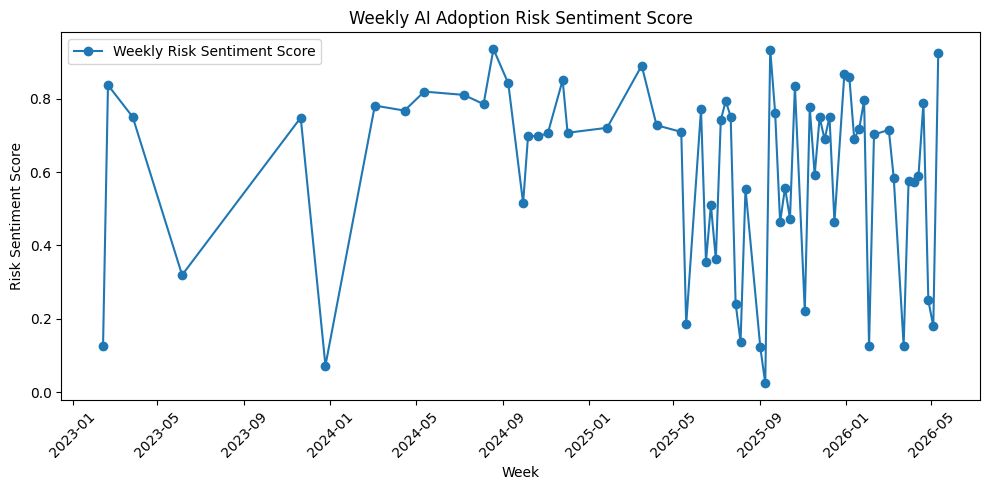

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_df["week"], weekly_df["risk_sentiment_score"], marker="o", label="Weekly Risk Sentiment Score")
plt.title("Weekly AI Adoption Risk Sentiment Score")
plt.xlabel("Week")
plt.ylabel("Risk Sentiment Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weekly_ai_risk_sentiment_score.png", dpi=150)
plt.show()


## 14. Baseline and Feedforward Neural Network

The historical mean baseline predicts the average training-period target. The feedforward neural network is the main model.


In [39]:
feature_columns = [
    "total_records",
    "risk_records",
    "avg_sentiment",
    "avg_negative_sentiment",
    "avg_risk_keyword_count",
    "risk_rate",
    "risk_sentiment_score",
    "lag_1_risk_sentiment_score",
    "lag_2_risk_sentiment_score",
    "lag_3_risk_sentiment_score",
    "lag_1_risk_rate",
    "lag_1_avg_sentiment",
    "lag_1_avg_negative_sentiment",
    "rolling_3_risk_sentiment_score",
    "rolling_4_risk_sentiment_score",
    "rolling_3_avg_sentiment",
    "rolling_3_risk_rate"
] + company_columns

X = weekly_model_df[feature_columns].copy()
y = weekly_model_df["target_next_week_risk_score"].copy()

# Chronological train/test split.
split_index = int(len(weekly_model_df) * 0.80)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
test_weeks = weekly_model_df["week"].iloc[split_index:]

print("Training weeks:", len(X_train))
print("Testing weeks:", len(X_test))

# Historical mean baseline.
baseline_prediction_value = y_train.mean()
baseline_predictions = np.repeat(baseline_prediction_value, len(y_test))
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))

print("Historical Mean Baseline")
print("MAE:", round(baseline_mae, 4))
print("RMSE:", round(baseline_rmse, 4))

# Scale features before neural network training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Small feedforward neural network.
model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.15),
    Dense(8, activation="relu"),
    Dense(1, activation="linear")
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=300,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

nn_predictions = model.predict(X_test_scaled).flatten()
nn_predictions = np.clip(nn_predictions, 0, 1)

nn_mae = mean_absolute_error(y_test, nn_predictions)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_predictions))

print("Feedforward Neural Network")
print("MAE:", round(nn_mae, 4))
print("RMSE:", round(nn_rmse, 4))


Training weeks: 49
Testing weeks: 13
Historical Mean Baseline
MAE: 0.2158
RMSE: 0.2788
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 1.2257 - mae: 0.9256 - val_loss: 1.3321 - val_mae: 1.0884
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.2112 - mae: 0.9198 - val_loss: 1.1899 - val_mae: 1.0288
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8692 - mae: 0.7897 - val_loss: 1.0605 - val_mae: 0.9713
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8469 - mae: 0.7979 - val_loss: 0.9335 - val_mae: 0.9102
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.6159 - mae: 0.6710 - val_loss: 0.8269 - val_mae: 0.8553
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5723 - mae: 0.6511 - val_loss: 0.7261 - val_mae: 0.7993
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3562 - mae: 0.5302 - val_loss: 0.6337 - val_mae: 0.7437
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.4289 - mae: 0.5297 - val_loss: 0.5505 - val_mae: 0.6895
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.3504 - mae: 0.4739 - val

## 15. Model Results and Prediction Chart


Saved model results to: ai_risk_company_final_outputs/model_results_baseline_vs_feedforward_nn.csv


,model,mae,rmse
0,Historical Mean Baseline,0.215763,0.278821
1,Feedforward Neural Network,0.274812,0.379821


Saved prediction results to: ai_risk_company_final_outputs/prediction_results_actual_vs_feedforward_nn.csv


,week,actual_next_week_risk_score,historical_mean_prediction,feedforward_nn_prediction
0,2026-01-19,0.795881,0.627264,0.653298
1,2026-01-26,0.125000,0.627264,0.000000
2,2026-02-02,0.702478,0.627264,0.625224
3,2026-02-09,0.715025,0.627264,0.000000
4,2026-03-02,0.583189,0.627264,0.494165


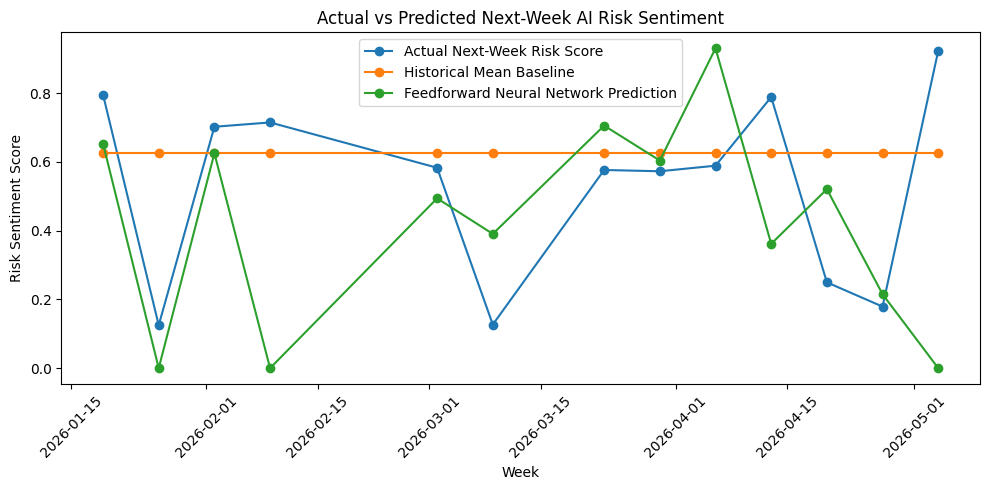

In [40]:
model_results = pd.DataFrame([
    {"model": "Historical Mean Baseline", "mae": baseline_mae, "rmse": baseline_rmse},
    {"model": "Feedforward Neural Network", "mae": nn_mae, "rmse": nn_rmse}
])

model_results_path = OUTPUT_DIR / "model_results_baseline_vs_feedforward_nn.csv"
model_results.to_csv(model_results_path, index=False)
print("Saved model results to:", model_results_path)
display(model_results)

prediction_results = pd.DataFrame({
    "week": test_weeks.values,
    "actual_next_week_risk_score": y_test.values,
    "historical_mean_prediction": baseline_predictions,
    "feedforward_nn_prediction": nn_predictions
})

prediction_results_path = OUTPUT_DIR / "prediction_results_actual_vs_feedforward_nn.csv"
prediction_results.to_csv(prediction_results_path, index=False)
print("Saved prediction results to:", prediction_results_path)
display(prediction_results.head())

plt.figure(figsize=(10, 5))
plt.plot(prediction_results["week"], prediction_results["actual_next_week_risk_score"], marker="o", label="Actual Next-Week Risk Score")
plt.plot(prediction_results["week"], prediction_results["historical_mean_prediction"], marker="o", label="Historical Mean Baseline")
plt.plot(prediction_results["week"], prediction_results["feedforward_nn_prediction"], marker="o", label="Feedforward Neural Network Prediction")
plt.title("Actual vs Predicted Next-Week AI Risk Sentiment")
plt.xlabel("Week")
plt.ylabel("Risk Sentiment Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted_feedforward_nn.png", dpi=150)
plt.show()


## 16. Training Log, Model, and Scaler


In [41]:
training_log = pd.DataFrame(history.history)
training_log["epoch"] = training_log.index + 1

training_log_path = OUTPUT_DIR / "feedforward_nn_training_log.csv"
training_log.to_csv(training_log_path, index=False)
print("Saved training log to:", training_log_path)

model_path = OUTPUT_DIR / "feedforward_nn_model.keras"
scaler_path = OUTPUT_DIR / "feedforward_nn_scaler.pkl"

model.save(model_path)
joblib.dump(scaler, scaler_path)

print("Saved model to:", model_path)
print("Saved scaler to:", scaler_path)

display(training_log.tail())


Saved training log to: ai_risk_company_final_outputs/feedforward_nn_training_log.csv
Saved model to: ai_risk_company_final_outputs/feedforward_nn_model.keras
Saved scaler to: ai_risk_company_final_outputs/feedforward_nn_scaler.pkl


,loss,mae,val_loss,val_mae,epoch
109,0.039912,0.165562,0.059199,0.195133,110
110,0.035056,0.148553,0.059455,0.195591,111
111,0.029475,0.140171,0.060356,0.196268,112
112,0.033783,0.153846,0.060442,0.195060,113
113,0.035138,0.151496,0.060959,0.195103,114


## 17. Power BI CSV Exports

These exports are for dashboard use.


In [44]:
# Record-level export for filtering by source, company/topic, and risk label.
powerbi_records = df[[
    "created_at", "week", "month", "source", "company_or_topic",
    "risk_label", "risk_keyword_count", "vader_compound",
    "negative_sentiment_score", "record_risk_sentiment_score",
    "title", "clean_text", "url"
]].copy()

powerbi_records_path = OUTPUT_DIR / "powerbi_record_level_export.csv"
powerbi_records.to_csv(powerbi_records_path, index=False)

# Weekly trend export.
powerbi_weekly_path = OUTPUT_DIR / "powerbi_weekly_trend_export.csv"
weekly_df.to_csv(powerbi_weekly_path, index=False)

# Company/topic summary export.
company_dashboard = df.groupby("company_or_topic").agg(
    total_records=("risk_label", "count"),
    risk_records=("risk_label", "sum"),
    avg_sentiment=("vader_compound", "mean"),
    avg_risk_sentiment_score=("record_risk_sentiment_score", "mean"),
    avg_risk_keyword_count=("risk_keyword_count", "mean")
).reset_index()
company_dashboard["risk_rate"] = company_dashboard["risk_records"] / company_dashboard["total_records"]

company_dashboard_path = OUTPUT_DIR / "powerbi_company_topic_summary.csv"
company_dashboard.to_csv(company_dashboard_path, index=False)

# Prediction results export.
powerbi_predictions_path = OUTPUT_DIR / "powerbi_prediction_results.csv"
prediction_results.to_csv(powerbi_predictions_path, index=False)

print("Saved Power BI record-level export to:", powerbi_records_path)
print("Saved Power BI weekly trend export to:", powerbi_weekly_path)
print("Saved Power BI company/topic summary to:", company_dashboard_path)
print("Saved Power BI prediction export to:", powerbi_predictions_path)

display(company_dashboard)


Saved Power BI record-level export to: ai_risk_company_final_outputs/powerbi_record_level_export.csv
Saved Power BI weekly trend export to: ai_risk_company_final_outputs/powerbi_weekly_trend_export.csv
Saved Power BI company/topic summary to: ai_risk_company_final_outputs/powerbi_company_topic_summary.csv
Saved Power BI prediction export to: ai_risk_company_final_outputs/powerbi_prediction_results.csv


,company_or_topic,total_records,risk_records,avg_sentiment,avg_risk_sentiment_score,avg_risk_keyword_count,risk_rate
0,Anthropic,87,52,0.119268,0.516298,0.965517,0.597701
1,Google,20,19,0.401780,0.717278,1.250000,0.950000
2,Meta,17,12,0.211276,0.591532,1.764706,0.705882
3,Microsoft,8,8,0.198850,0.787644,1.875000,1.000000
4,Multiple,32,22,0.251878,0.566015,1.375000,0.687500
5,OpenAI,140,108,0.044021,0.647926,1.364286,0.771429
6,xAI,17,12,0.096900,0.591711,1.000000,0.705882
